# Fraud Detection — Feature Engineering

Builds the model-ready feature set from `fraudTrain.csv` / `fraudTest.csv`, based on the EDA notebook's column decisions and test-set structural checks. Constants and paths are centralised in `config.py`.

## 1. Setup and load

In [1]:
cd ../

/Users/ann/Documents/Zempler/fraud_datasets


In [2]:
import numpy as np
import pandas as pd

import src.config as config

np.random.seed(config.RANDOM_SEED)
pd.options.display.max_columns = 40

In [3]:
df_train = pd.read_csv(config.TRAIN_RAW_PATH, index_col=0)
df_test = pd.read_csv(config.TEST_RAW_PATH, index_col=0)

df_train["trans_time"] = pd.to_datetime(df_train["trans_date_trans_time"])
df_test["trans_time"] = pd.to_datetime(df_test["trans_date_trans_time"])

df_train = df_train.sort_values(["cc_num", "trans_time"]).reset_index(drop=True)
df_test = df_test.sort_values(["cc_num", "trans_time"]).reset_index(drop=True)

df_train.shape, df_test.shape

((1296675, 23), (555719, 23))

## 2. Column decisions applied

Dropping identifiers and fairness-excluded fields up front (`config.DROP_COLS`) so they can't end up in the model later.

In [4]:
df_train = df_train.drop(columns=config.DROP_COLS)
df_test = df_test.drop(columns=config.DROP_COLS)

## 3. Time-based features

In [5]:
def add_time_features(df):
    df = df.copy()
    df["trans_hour"] = df["trans_time"].dt.hour
    df["trans_dayofweek"] = df["trans_time"].dt.dayofweek  # 0 = Monday
    df["is_evening_risk"] = df["trans_hour"].isin(config.EVENING_RISK_HOURS).astype(int)
    df["is_late_night_risk"] = df["trans_hour"].isin(config.LATE_NIGHT_RISK_HOURS).astype(int)
    return df

df_train = add_time_features(df_train)
df_test = add_time_features(df_test)

<Axes: xlabel='trans_dayofweek'>

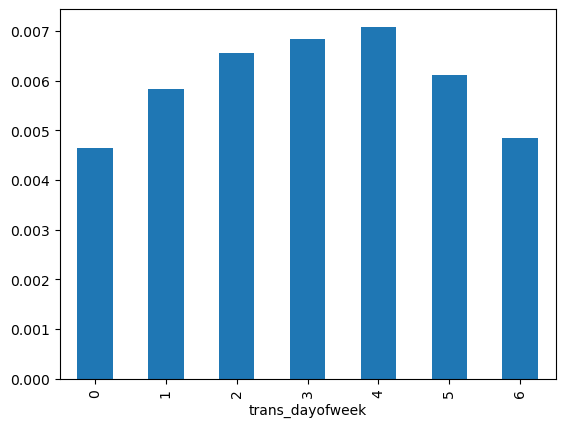

In [6]:
df_train.groupby("trans_dayofweek", observed=True)["is_fraud"].mean().plot(kind="bar")

## 5. Age features

`dob` is dropped; only derived `age`/`age_band` go into the model.

In [7]:
def add_age_features(df):
    df = df.copy()
    dob = pd.to_datetime(df["dob"])
    df["age"] = ((df["trans_time"] - dob).dt.days / 365.25).astype(int)
    df["age_band"] = pd.cut(df["age"], bins=config.AGE_BIN_EDGES)
    return df.drop(columns=["dob"])

df_train = add_age_features(df_train)
df_test = add_age_features(df_test)

## 6. City population band

In [8]:
df_train["city_pop_band"], city_pop_bins = pd.qcut(
    df_train["city_pop"], config.CITY_POP_N_BINS, duplicates="drop", retbins=True
)
df_test["city_pop_band"] = pd.cut(df_test["city_pop"], bins=city_pop_bins, include_lowest=True)

## 7. Merchant category features

`category` is kept directly (14 levels, tree models split on it natively). `merch_channel` (_net/_pos/other) adds a lower-cardinality feature capturing the same online-vs-in-person risk split EDA showed, without hand-picking specific categories.

In [9]:
def add_category_features(df):
    df = df.copy()
    df["category"] = df["category"].astype("category")
    df["merch_channel"] = np.where(
        df["category"].str.endswith("_net"), "online",
        np.where(df["category"].str.endswith("_pos"), "in_person", "other")
    )
    return df

df_train = add_category_features(df_train)
df_test = add_category_features(df_test)

df_train.groupby("merch_channel", observed=True)["is_fraud"].mean()

merch_channel
in_person    0.008863
online       0.013389
other        0.002477
Name: is_fraud, dtype: float64

**Not built:** a fixed `shopping_net`/`misc_net`/`grocery_pos` "high risk category" flag. `category` already gives the model this information and there's no clear behavioural justification for grouping these categories.

## 8. Time since last transaction (customer level)

As built in EDA, with the train→test carry-forward join applied: only 16 test customers are genuinely new, and train ends 52 seconds before test begins — without the join, ~984 returning customers would be wrongly flagged as cold-start.

In [10]:
def add_time_since_last_train(df):
    df = df.copy()
    df["prev_trans_time"] = df.groupby("cc_num")["trans_time"].shift(1)
    df["time_since_last_trans_mins"] = (
        (df["trans_time"] - df["prev_trans_time"]).dt.total_seconds() / 60
    )
    df["is_first_transaction"] = df["prev_trans_time"].isna().astype(int)
    return df

df_train = add_time_since_last_train(df_train)
df_train["is_first_transaction"].value_counts()

is_first_transaction
0    1295692
1        983
Name: count, dtype: int64

In [11]:
# Carry the last known transaction time per customer forward from train into test
last_train_time = df_train.groupby("cc_num")["trans_time"].max()

df_test["prev_trans_time"] = df_test.groupby("cc_num")["trans_time"].shift(1)
first_row_mask = df_test["prev_trans_time"].isna()
df_test.loc[first_row_mask, "prev_trans_time"] = (
    df_test.loc[first_row_mask, "cc_num"].map(last_train_time)
)

df_test["time_since_last_trans_mins"] = (
    (df_test["trans_time"] - df_test["prev_trans_time"]).dt.total_seconds() / 60
)
# Genuinely new customers (not in train) still correctly show as first transaction
df_test["is_first_transaction"] = df_test["prev_trans_time"].isna().astype(int)
df_test["is_first_transaction"].value_counts()  

is_first_transaction
0    555703
1        16
Name: count, dtype: int64

## 9. Amount features

`amt` kept as-is. Also adding binned amounts due to relationship found in EDA

In [12]:
df_train["amt_band"] = pd.cut(df_train["amt"], bins=config.AMT_BIN_EDGES, include_lowest=True)
df_test["amt_band"] = pd.cut(df_test["amt"], bins=config.AMT_BIN_EDGES, include_lowest=True)

## 10. Assemble final feature set

Feature list now lives in `config.py` (`FEATURE_COLS`). same small-sample risk flagged for `state`. `city_pop_band` is included as a candidate.

In [13]:
model_train = df_train[config.ID_COLS + config.FEATURE_COLS + [config.TARGET_COL]].copy()
model_test = df_test[config.ID_COLS + config.FEATURE_COLS + [config.TARGET_COL]].copy()

# Interval dtype (from pd.cut/qcut) isn't supported by the parquet writer -- storing as string.
for col in ["age_band", "city_pop_band", "amt_band"]:
    model_train[col] = model_train[col].astype(str)
    model_test[col] = model_test[col].astype(str)

model_train.shape, model_test.shape

((1296675, 15), (555719, 15))

Sanity check: missing values should only appear where expected (`time_since_last_trans_mins` for first transactions).

In [14]:
model_train[config.FEATURE_COLS].isna().sum()

category                        0
merch_channel                   0
age_band                        0
city_pop_band                   0
amt_band                        0
trans_hour                      0
trans_dayofweek                 0
is_evening_risk                 0
is_late_night_risk              0
time_since_last_trans_mins    983
is_first_transaction            0
dtype: int64

In [15]:
model_test[config.FEATURE_COLS].isna().sum()

category                       0
merch_channel                  0
age_band                       0
city_pop_band                  0
amt_band                       0
trans_hour                     0
trans_dayofweek                0
is_evening_risk                0
is_late_night_risk             0
time_since_last_trans_mins    16
is_first_transaction           0
dtype: int64

## 11. Save engineered datasets

In [16]:
config.PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
model_train.to_parquet(config.TRAIN_PROCESSED_PATH, index=False)
model_test.to_parquet(config.TEST_PROCESSED_PATH, index=False)

## 12. Feature engineering decision log

1. **Dropped `gender` and `state`** on fairness grounds, despite `gender` showing a real (small) effect.
2. **Dropped the hand-picked "high risk category" flag** in favour of raw `category` + `merch_channel`. the flag's ranking hadn't been checked for stability over time, and there was no principled way to group categories into risk tiers without cherry-picking on a single window of data. Left category at full cardinality; regularization (L2, default in the modelling pipeline) handles the sparser levels, though this hasn't been tested against a grouped alternative.
3. **Two hour flags instead of one** (`is_evening_risk`, `is_late_night_risk`). Hourly plot showed 2 distinct high-risk bands, not one continuous stretch.